# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import joblib
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make Dataset

In [ ]:
random.seed(42)

# -----------------------------
# Plant categories
# -----------------------------

plant_types = [
    "Indoor Plant",
    "Flower Plant",
    "Vegetable Plant",
    "Herb",
    "Succulent",
    "Leafy Ornamental"
]

locations = [
    "Indoor",
    "Rooftop",
    "Balcony",
    "Outdoor Garden"
]

sunlight_levels = ["Low", "Medium", "High"]

soil_types = ["Sandy", "Loamy", "Clay", "Potting Mix"]

moisture_levels = ["Low", "Medium", "High"]

fertilizers = [
    "Compost",
    "Vermicompost",
    "Balanced NPK",
    "Nitrogen Rich",
    "Phosphorus Rich",
    "Liquid Fertilizer",
    "Bone Meal",
    "Seaweed Fertilizer"
]

# -----------------------------
# Fertilizer recommendation logic
# -----------------------------

def recommend_fertilizer(plant, n, p, k, ph):

    if n < 35 and p >= 35:
        return "Nitrogen Rich"

    if p < 35 and n >= 35:
        return "Phosphorus Rich"

    if k < 35:
        return "Balanced NPK"

    if plant == "Flower Plant":
        return "Bone Meal"

    if plant == "Indoor Plant":
        return "Liquid Fertilizer"

    if plant == "Succulent":
        return "Compost"

    return "Vermicompost"

# -----------------------------
# Dataset generation
# -----------------------------

rows = []
DATASET_SIZE = 10000

for i in range(DATASET_SIZE):

    plant = random.choice(plant_types)
    location = random.choice(locations)
    sunlight = random.choice(sunlight_levels)
    soil = random.choice(soil_types)
    moisture = random.choice(moisture_levels)

    nitrogen = random.randint(20, 80)
    phosphorus = random.randint(20, 80)
    potassium = random.randint(20, 80)

    soil_ph = round(random.uniform(5.0, 7.5), 1)

    fertilizer = recommend_fertilizer(
        plant,
        nitrogen,
        phosphorus,
        potassium,
        soil_ph
    )

    rows.append([
        plant,
        location,
        sunlight,
        soil,
        moisture,
        nitrogen,
        phosphorus,
        potassium,
        soil_ph,
        fertilizer
    ])

columns = [
    "plant_type",
    "location",
    "sunlight",
    "soil_type",
    "soil_moisture",
    "nitrogen",
    "phosphorus",
    "potassium",
    "soil_ph",
    "recommended_fertilizer"
]

df = pd.DataFrame(rows, columns=columns)

df.to_csv("rooftop_garden_fertilizer_dataset.csv", index=False)

print("Dataset generated successfully!")
print(df.head())
print("Dataset shape:", df.shape)

Dataset generated successfully!
         plant_type location sunlight    soil_type soil_moisture  nitrogen  \
0  Leafy Ornamental   Indoor      Low         Clay           Low        34   
1  Leafy Ornamental   Indoor     High  Potting Mix           Low        21   
2         Succulent   Indoor     High        Loamy          High        61   
3              Herb  Balcony      Low        Loamy          High        47   
4   Vegetable Plant   Indoor      Low  Potting Mix           Low        42   

   phosphorus  potassium  soil_ph recommended_fertilizer  
0          28         67      5.3           Vermicompost  
1          25         33      5.6           Balanced NPK  
2          64         54      6.0                Compost  
3          41         37      5.4           Vermicompost  
4          74         42      6.5           Vermicompost  
Dataset shape: (10000, 10)


# Import Dataset

In [3]:
try:
    df = pd.read_csv('rooftop_garden_fertilizer_dataset.csv')
    print("Dataset imported successfully!")
except FileNotFoundError:
    print("Dataset not found. Please make sure the file is in the correct location.")

Dataset imported successfully!


# Data Analysis

In [4]:
df.head(3)

,plant_type,location,sunlight,soil_type,soil_moisture,nitrogen,phosphorus,potassium,soil_ph,recommended_fertilizer
0,Leafy Ornamental,Indoor,Low,Clay,Low,34,28,67,5.3,Nitrogen Rich
1,Leafy Ornamental,Indoor,High,Potting Mix,Low,21,25,33,5.6,Nitrogen Rich
2,Succulent,Indoor,High,Loamy,High,61,64,54,6.0,Compost


In [5]:
print(df["recommended_fertilizer"].value_counts(normalize=True))

recommended_fertilizer
Nitrogen Rich        0.3845
Balanced NPK         0.1982
Phosphorus Rich      0.1863
Liquid Fertilizer    0.0754
Bone Meal            0.0709
Compost              0.0702
Vermicompost         0.0145
Name: proportion, dtype: float64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   plant_type              10000 non-null  object 
 1   location                10000 non-null  object 
 2   sunlight                10000 non-null  object 
 3   soil_type               10000 non-null  object 
 4   soil_moisture           10000 non-null  object 
 5   nitrogen                10000 non-null  int64  
 6   phosphorus              10000 non-null  int64  
 7   potassium               10000 non-null  int64  
 8   soil_ph                 10000 non-null  float64
 9   recommended_fertilizer  10000 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 781.4+ KB


In [7]:
df['recommended_fertilizer'].value_counts()

,count
recommended_fertilizer,
Nitrogen Rich,3845
Balanced NPK,1982
Phosphorus Rich,1863
Liquid Fertilizer,754
Bone Meal,709
Compost,702
Vermicompost,145


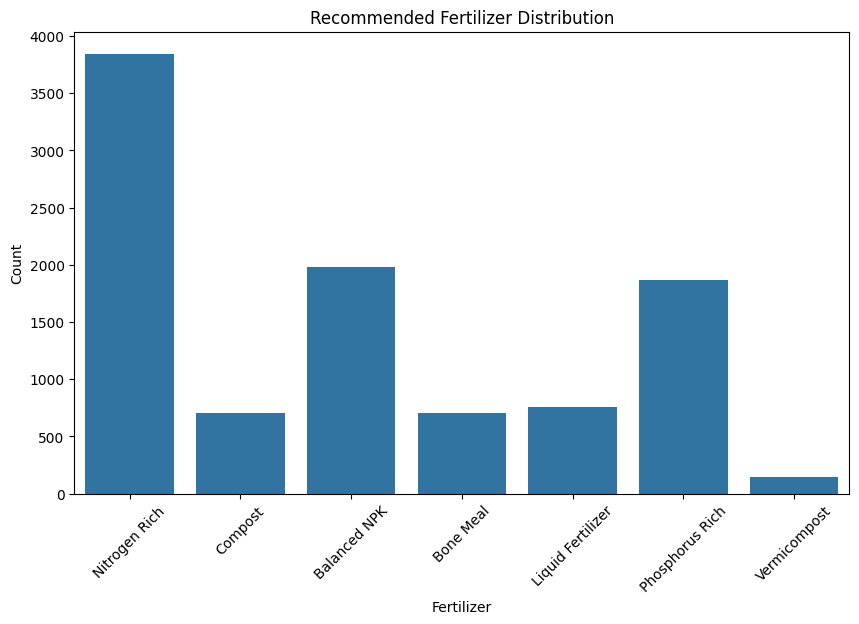

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='recommended_fertilizer')
plt.xticks(rotation=45)
plt.xlabel('Fertilizer')
plt.ylabel('Count')
plt.title('Recommended Fertilizer Distribution')
plt.show()

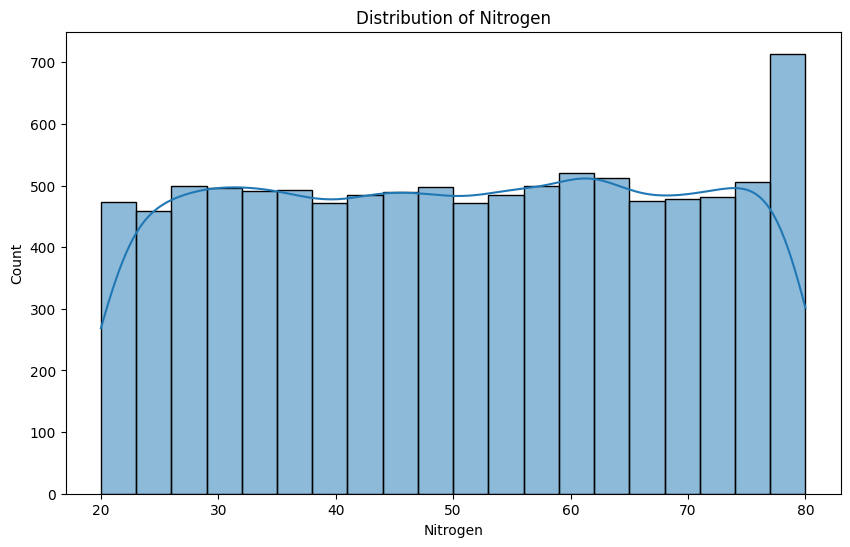

In [9]:
# nitrogen
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='nitrogen', bins=20, kde=True)
plt.xlabel('Nitrogen')
plt.ylabel('Count')
plt.title('Distribution of Nitrogen')
plt.show()

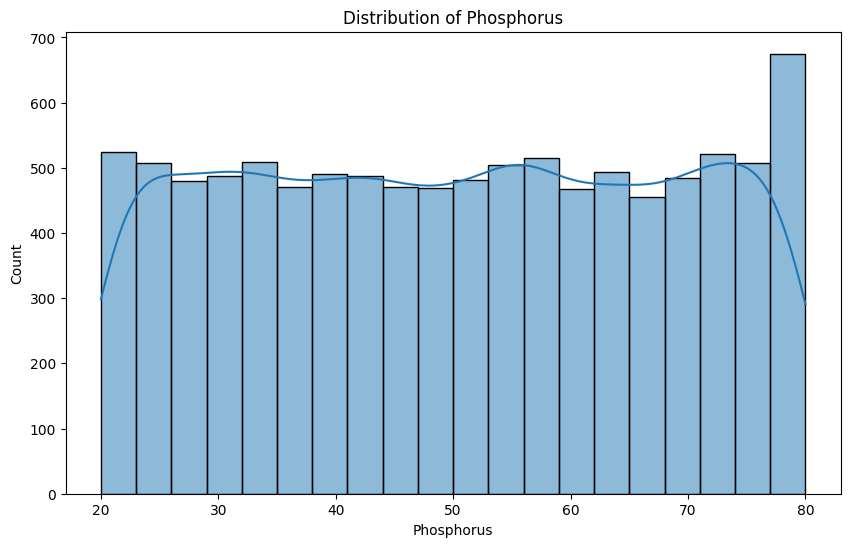

In [10]:
# phosphorus and potassium
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='phosphorus', bins=20, kde=True)
plt.xlabel('Phosphorus')
plt.ylabel('Count')
plt.title('Distribution of Phosphorus')
plt.show()

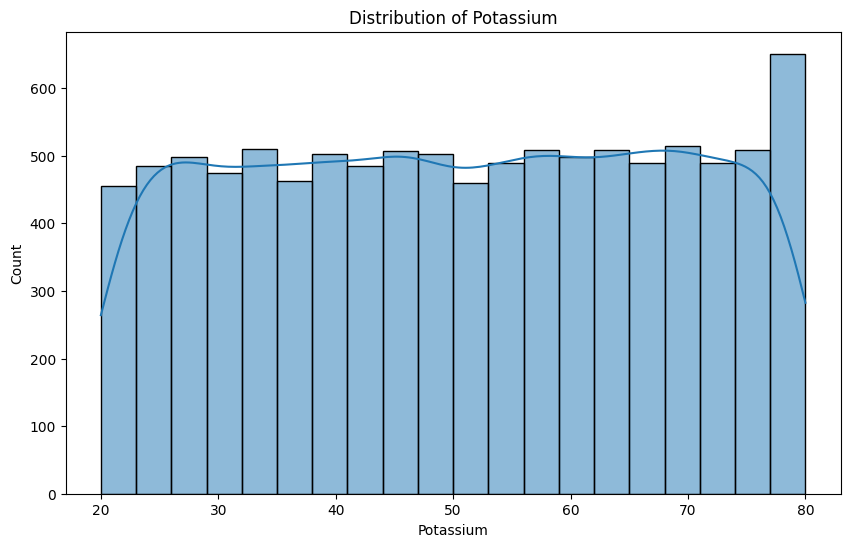

In [11]:
# potassium
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='potassium', bins=20, kde=True)
plt.xlabel('Potassium')
plt.ylabel('Count')
plt.title('Distribution of Potassium')
plt.show()

# Train Test Split

In [12]:
X = df.drop('recommended_fertilizer', axis=1)
y = df['recommended_fertilizer']

X.shape, y.shape

((10000, 9), (10000,))

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, y_test.shape

((8000, 9), (2000,))

# Transformation

## Define Feature Groups

In [14]:
categorical_cols = [
    "plant_type",
    "location",
    "soil_type"
]

ordinal_cols = [
    "sunlight",
    "soil_moisture"
]

numerical_cols = [
    "nitrogen",
    "phosphorus",
    "potassium",
    "soil_ph"
]

## ColumnTransformer

In [15]:
preprocessor = ColumnTransformer(
    transformers=[

        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),

        ("ord", OrdinalEncoder(), ordinal_cols),

        ("num", StandardScaler(), numerical_cols)

    ]
)

# Build ML Pipeline

In [16]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=1000,
            max_depth=10,
            random_state=42
        ))
    ]
)

# Train the Model

In [17]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['plant_type', 'location',
                                                   'soil_type']),
                                                 ('ord', OrdinalEncoder(),
                                                  ['sunlight',
                                                   'soil_moisture']),
                                                 ('num', StandardScaler(),
                                                  ['nitrogen', 'phosphorus',
                                                   'potassium', 'soil_ph'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=1000,
                                        random_state=42))])

# Make Predictions

In [18]:
predictions = rf_pipeline.predict(X_test)

# Evaluate Model

In [19]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [20]:
class_report = classification_report(y_test, predictions)

print("Classification Report:\n", class_report)

Classification Report:
                    precision    recall  f1-score   support

     Balanced NPK       1.00      1.00      1.00       435
        Bone Meal       1.00      1.00      1.00       122
          Compost       1.00      1.00      1.00       141
Liquid Fertilizer       1.00      1.00      1.00       152
    Nitrogen Rich       1.00      1.00      1.00       772
  Phosphorus Rich       1.00      1.00      1.00       356
     Vermicompost       1.00      1.00      1.00        22

         accuracy                           1.00      2000
        macro avg       1.00      1.00      1.00      2000
     weighted avg       1.00      1.00      1.00      2000



In [21]:
train_predictions = rf_pipeline.predict(X_train)
train_acc = accuracy_score(y_train, train_predictions)
test_acc = accuracy_score(y_test, predictions)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 1.0


In [23]:
scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5)

print("CV Scores:", scores)
print("Mean CV Score:", scores.mean())

CV Scores: [1. 1. 1. 1. 1.]
Mean CV Score: 1.0


# Predict Fertilizer for New User

In [24]:
sample = pd.DataFrame([{
    "plant_type": "Flower Plant",
    "location": "Rooftop",
    "sunlight": "High",
    "soil_type": "Loamy",
    "soil_moisture": "Medium",
    "nitrogen": 30,
    "phosphorus": 25,
    "potassium": 40,
    "soil_ph": 6.5
}])

result = rf_pipeline.predict(sample)

print("Recommended Fertilizer:", result[0])

Recommended Fertilizer: Nitrogen Rich


# Top `k` Recomendation

In [25]:
sample = pd.DataFrame([{
    "plant_type": "Flower Plant",
    "location": "Rooftop",
    "sunlight": "High",
    "soil_type": "Loamy",
    "soil_moisture": "Medium",
    "nitrogen": 30,
    "phosphorus": 25,
    "potassium": 40,
    "soil_ph": 6.5
}])

probs = rf_pipeline.predict_proba(sample)

classes = rf_pipeline.classes_

top3 = probs[0].argsort()[-3:][::-1]

print("Recommended Fertilizers:\n")

for i in top3:
    print(f"{classes[i]}  ({probs[0][i]*100:.2f}%)")

Recommended Fertilizers:

Nitrogen Rich  (91.58%)
Phosphorus Rich  (7.53%)
Bone Meal  (0.83%)


# Logistic Regression

In [26]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegressionCV(random_state=42, cv=5))
    ]
)

lr_pipeline.fit(X_train, y_train)

lr_predictions = lr_pipeline.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8575


# Decision Tree

In [27]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(
            criterion='entropy',
            max_depth=10,
            random_state=42))
        ]
)

dt_pipeline.fit(X_train, y_train)

dt_predictions = dt_pipeline.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


# SVC

In [28]:
from sklearn.svm import SVC

svc_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", SVC(random_state=42, kernel='rbf', C=2))
    ]
)

svc_pipeline.fit(X_train, y_train)

svc_predictions = svc_pipeline.predict(X_test)

svc_accuracy = accuracy_score(y_test, svc_predictions)

print("SVC Accuracy:", svc_accuracy)

SVC Accuracy: 0.934


# KNN

In [29]:
from sklearn.neighbors import KNeighborsClassifier
knn_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", KNeighborsClassifier(
            n_neighbors=7,
            weights='distance',
            p=1,
            metric='minkowski',
            algorithm='kd_tree'
            ))
    ]
)

knn_pipeline.fit(X_train, y_train)

knn_predictions = knn_pipeline.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_predictions)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.825


# Naive Bayes

In [30]:
from sklearn.naive_bayes import BernoulliNB

nb_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", BernoulliNB())
    ]
)

nb_pipeline.fit(X_train, y_train)

nb_predictions = nb_pipeline.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.5425


# MLPClassifier

In [31]:
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),

        ("model", MLPClassifier(
            hidden_layer_sizes=(100, 200, 100),
            activation='relu',
            solver='adam',
            alpha=0.0001,
            batch_size='auto',
            learning_rate='constant',
            learning_rate_init=0.01,
            power_t=0.5,
            max_iter=200,
            shuffle=True,
            random_state=42,
            tol=0.0001,
            verbose=False,
            warm_start=False,
            momentum=0.9,
            nesterovs_momentum=True,
            early_stopping=False
        )
        )
    ]
)

mlp_pipeline.fit(X_train, y_train)

mlp_predictions = mlp_pipeline.predict(X_test)

mlp_accuracy = accuracy_score(y_test, mlp_predictions)

print("MLPClassifier Accuracy:", mlp_accuracy)

MLPClassifier Accuracy: 0.964


# Export Model

In [33]:
joblib.dump(rf_pipeline, "fertilizer_model.joblib")

print("Model exported successfully!")

Model exported successfully!


# Important Dataset

- [Plant Health Dataset](https://www.kaggle.com/datasets/souvikrana17/indoor-plant-health-and-growth-dataset)

- [Fertilizer Recommendation Dataset](https://www.kaggle.com/datasets/miadul/fertilizer-recommendation-dataset/data?select=fertilizer_recommendation.csv)

In [38]:
import sklearn, numpy, pandas, joblib
print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)

sklearn: 1.6.1
numpy: 2.0.2
pandas: 2.2.2
joblib: 1.5.3


In [40]:
!python --version

Python 3.12.12
